# Часть 1 — Множественное выравнивание

Я выбрал альфа субъединицу гемоглобина (Hemoglobin subunit alpha) для четырех разных по происхождению видов в базе UniProt:
 - Человек (Homo sapiens): P69905 (HBA_HUMAN)
 - Домовая мышь (Mus musculus): P01942 (HBA_MOUSE)
 - Зебраданио / Рыбка-зебра (Danio rerio): Q90487 (HBA_DANRE)
 - Египетская летучая собака (Rousettus aegyptiacus): P01956 (HBA_ROUAE)
 
Для проведения множественного выравнивания использовал сайт MUSCLE [https://www.ebi.ac.uk/jdispatcher/msa/muscle]

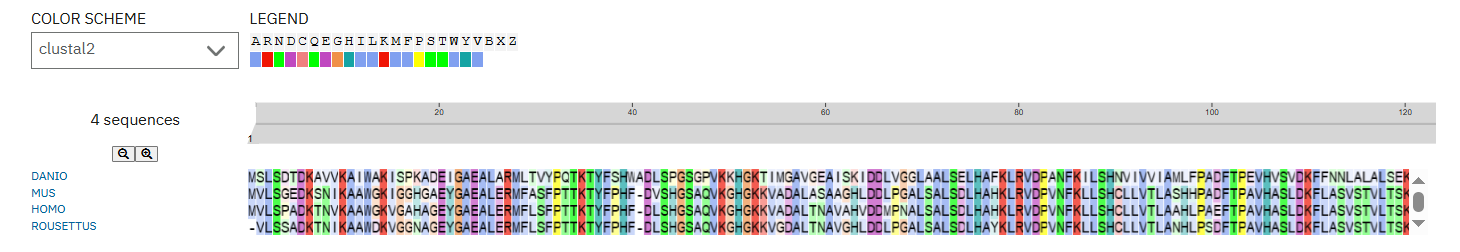

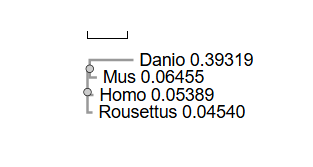

Получили Newick формат выравнивания:
`((Danio:0.39319, Mus:0.06455):0.02005, Homo:0.05389, Rousettus:0.04540);`

При помощи сайта iTOL (Interactive Tree Of Life)[https://itol.embl.de/] остроили филогенетическое дерево по полученному Newick в более читаемом формате
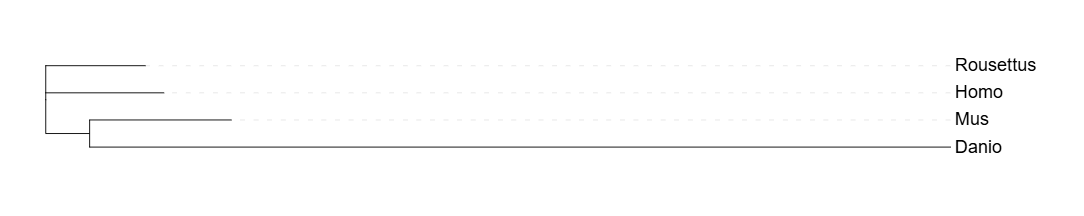

# Часть 2 — MEGA и коронавирус

Для последовательностей коронавируса сделали множественное выравнивание и построили филогенетическое дерево внутри программы MEGA

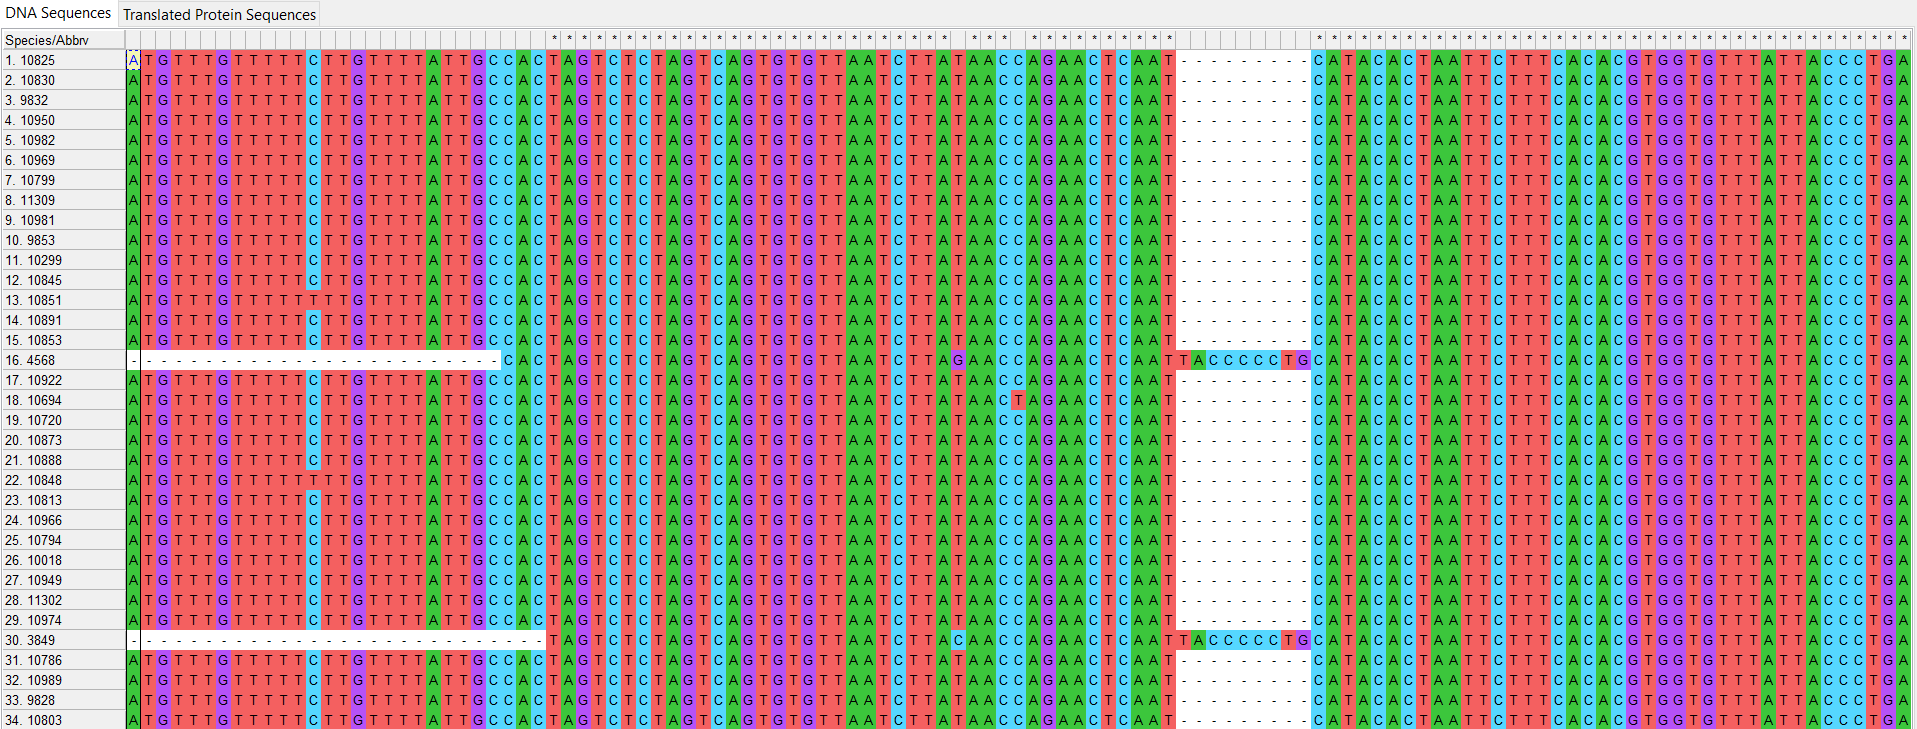

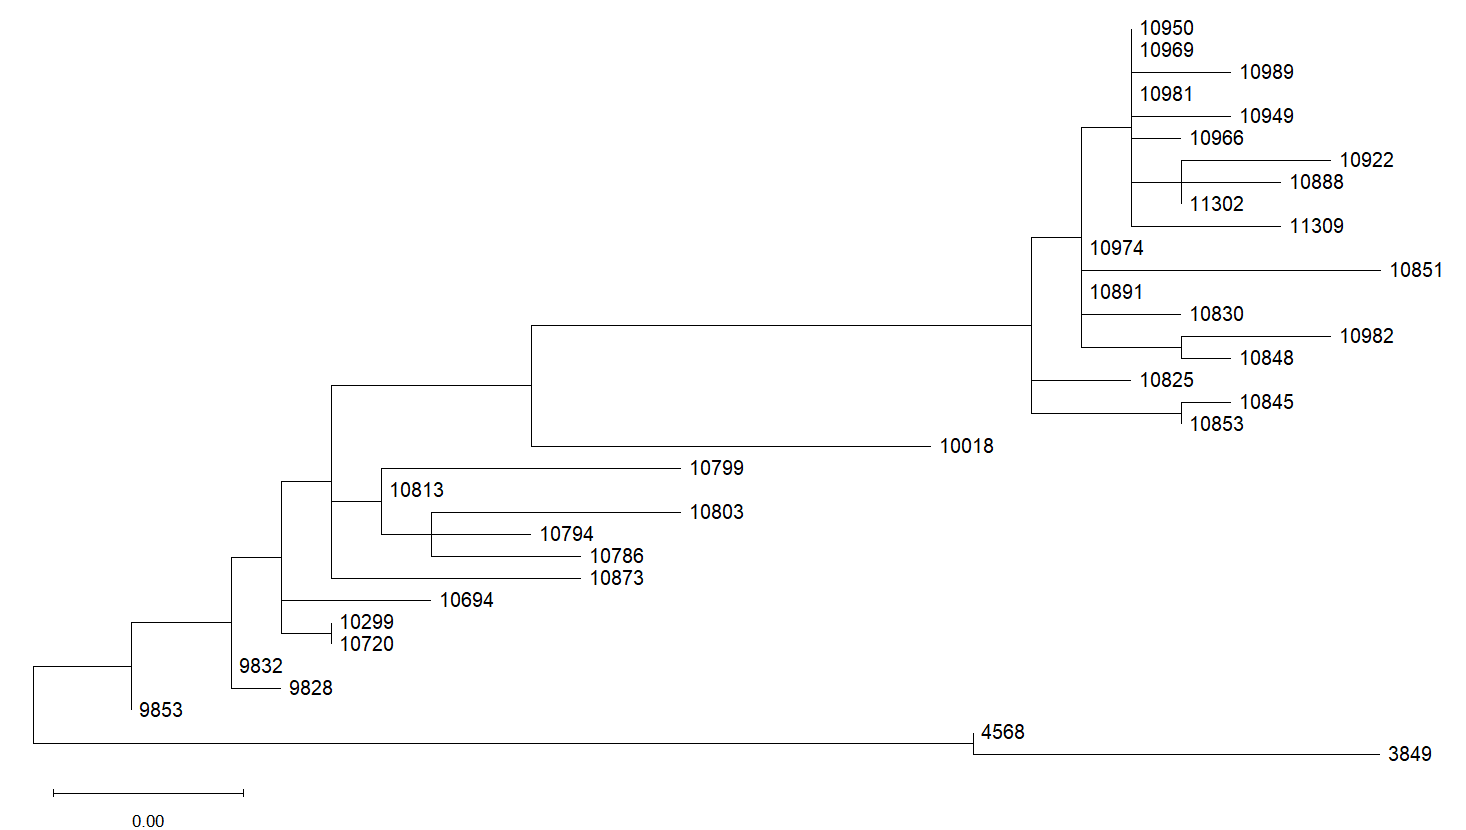

 - Образцы 4568 и 3849 значительно удалены от основной группы, представляя собой генетически отличные или более ранние линии.
 - Ступенчатое расположение некоторых ветвей отражает последовательный процесс эволюции вируса во времени
 - Верхняя правая группа ветвей имеет минимальную длину, что говорит о недавнем возникновении этих вариантов и малом количестве накопленных мутаций

В качестве 3 последовательности из других штаммов ковида были взяты последовательности с параметрами

 - Length: ~1270
 - Host: Homo sapiens
 - Geo Location: Nigeria: Osun State

Проведено множественное выравнивание, после этого данные были распределены в 2 группы и построено новое филогенетическое дерево

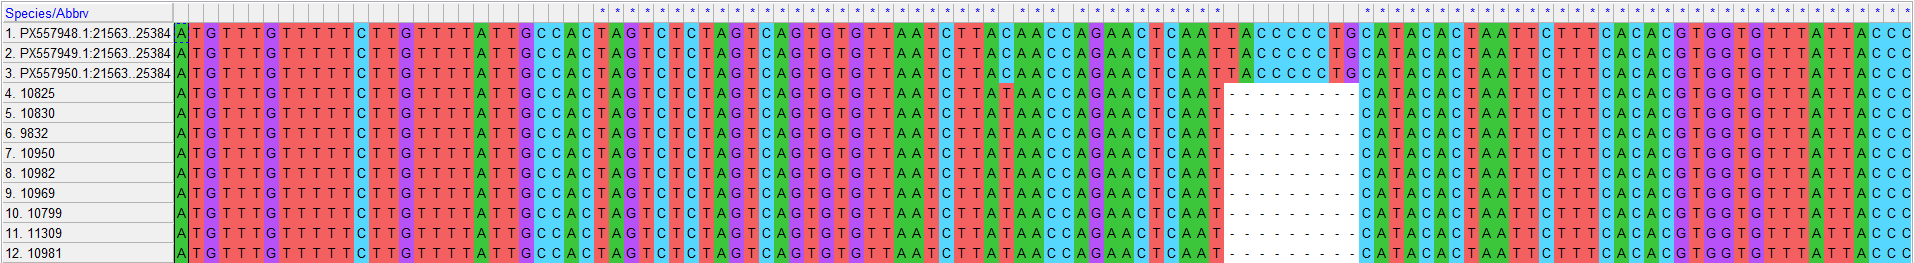

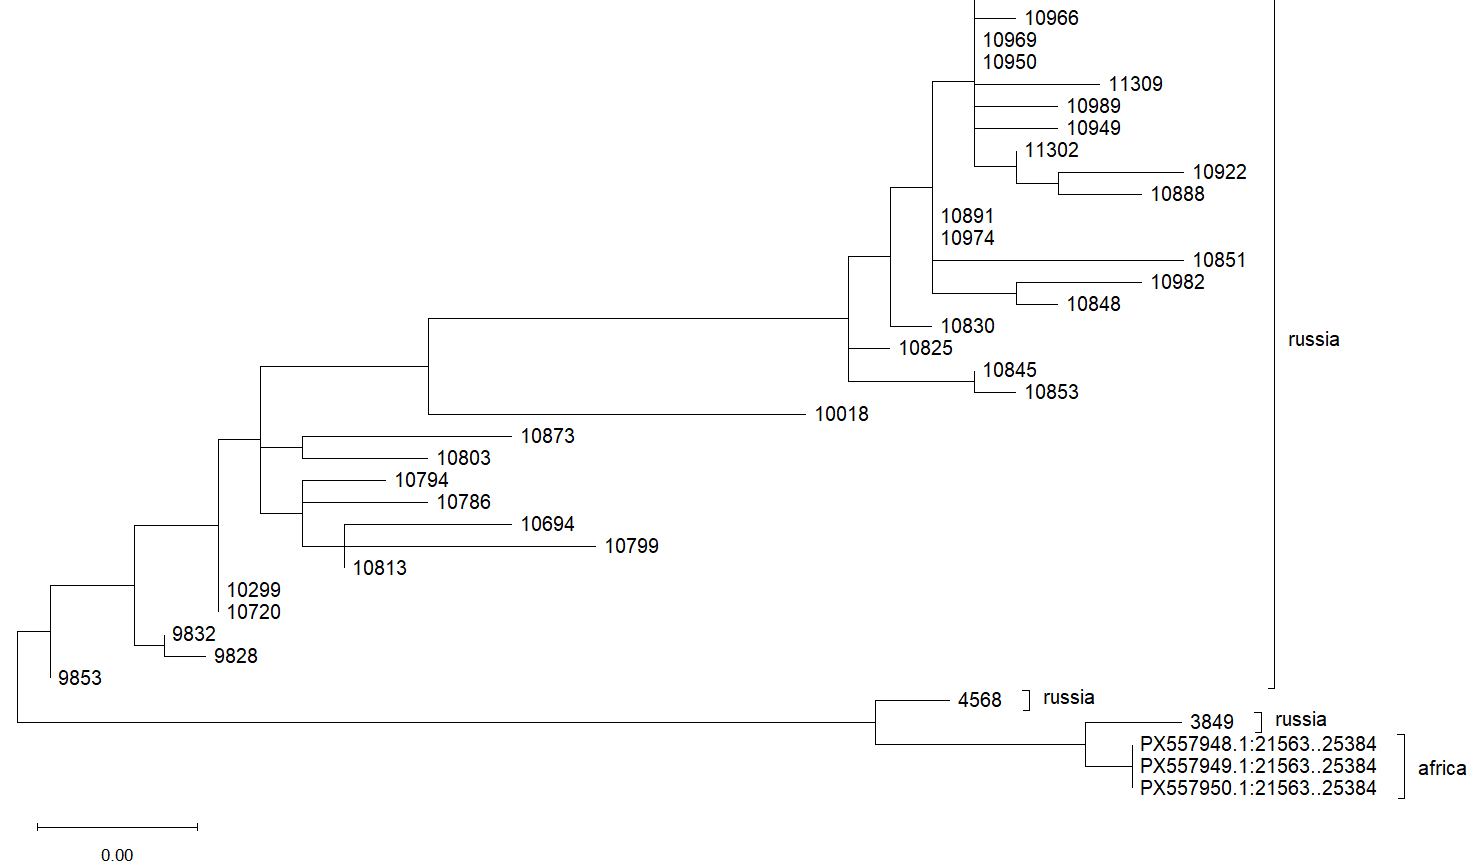

 - Все три последовательности из Африки сгруппированы вместе и значительно удалены от основного массива российских образцов
 - Некоторые образцы (4568, 3849) являются исключениями, лежащими ближе к африканским штаммам
 - У всех представленных вирусов был общий источник, от которого они начали эволюционировать в разных направлениях

#  Часть 3 — BLAST

По данной в задании части последовательности неизвестного белка `EGMQCSCGIDYYTPHEETNNESFVIYMFVVHFIIPLIVIFFCYGQLVFTVKEAAAQQQES`
 нашли белок, который кодирует данная последовательность используя базу банных nr

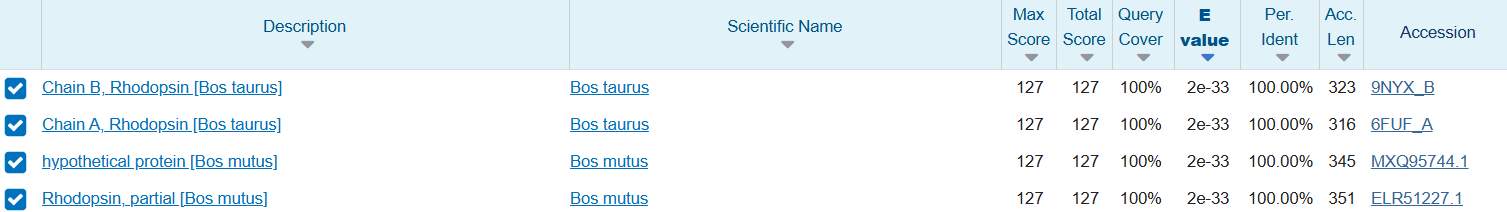

По первым строчкам запроса можно понять, что эта последовательность кодирует родопсин. Теперь попытаемся найти ортолог данного гена у человека. В этой задаче лучше использовать `blastp`, так как мы сравниваем белоковые последовательности и в процессе эволюции ДНК меняется быстрее, а аминокислотная последовательность белка остается стабильной дольше и поэтому является более консервативной. А в качестве базы данных возьмем `refseq_protein`, так как она исключает дублирование и ошибки аннотации, которые могут встретиться в nr

Наиболее похожим на исходный белок по результатам запроса оказался `rhodopsin [Homo sapiens]`
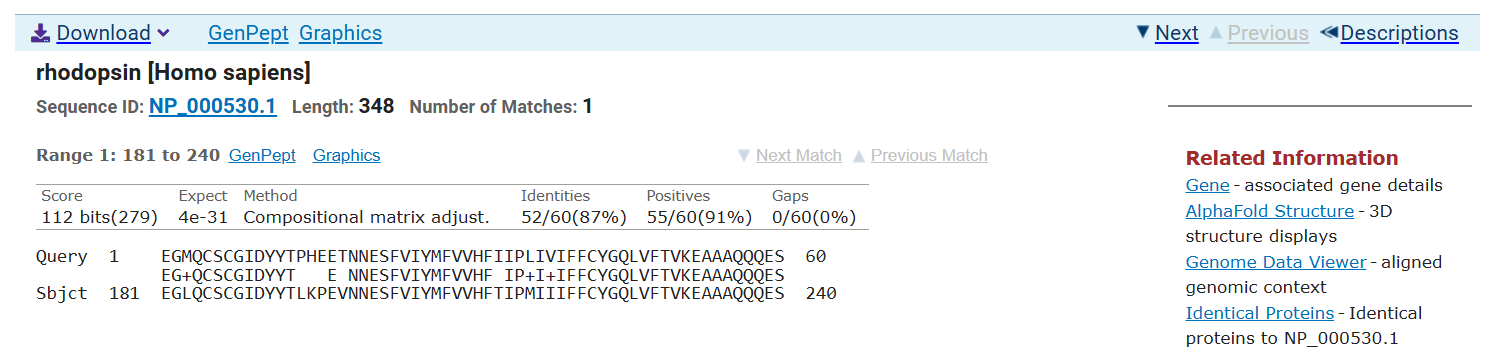

По id найденного белка нашли его же на UniProt и определили какие дефекты зрения у человека связаны с этим белком.  
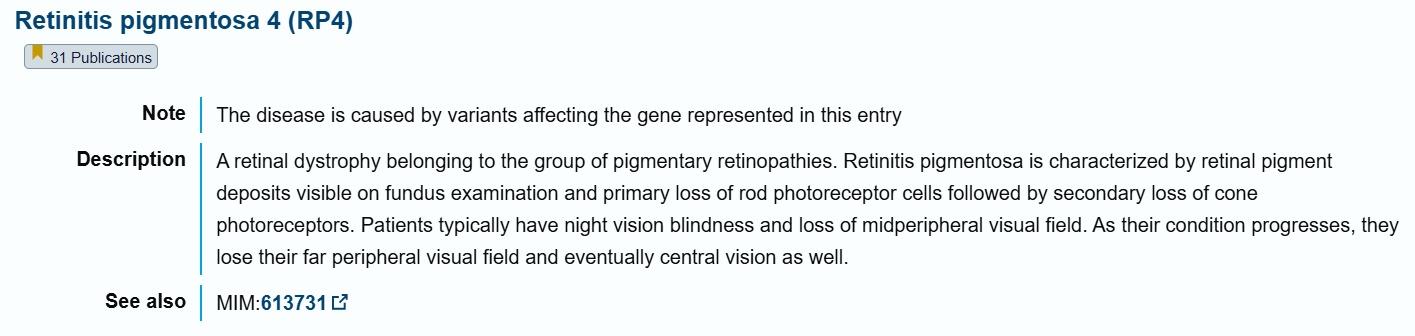
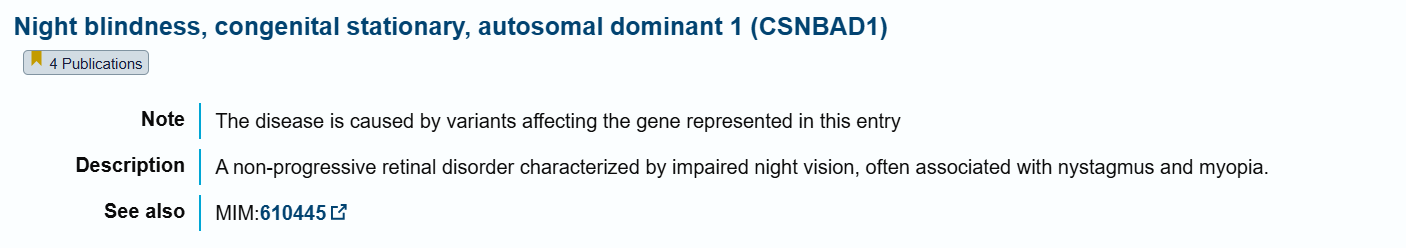

1. Установаили все необзодимые программы и утилиты: TransDecoder, BLAST, seqtk
2. Загрузили последовательность люциферазы `Luciola cruciata`, а также транскиптом Photinus pyralis (американский светлячок)
3. Нашли в РНК открытые рамки считывания и перевести их в аминокислотную последовательность командой
    
    ```TransDecoder.LongOrfs -t ppyralis_transcriptome.fasta```
    
4. Создали BLAST-базу данных командой

    ```makeblastdb -in ppyralis_transcriptome.fasta.transdecoder_dir/longest_orfs.pep -dbtype prot -out ppyralis_blastdb```
    
5. Запустили поиск белка lcruciata_luc.fasta по нашей новой базе данных

    ```blastp -query lcruciata_luc.fasta -db ppyralis_blastdb -outfmt 6 -max_target_seqs 10 -num_threads 2 -out blast_results.txt```
    
6. Мы получили файл blast_results.txt с 10 строками. Сохраняем последовательности с помощью seqtk subseq

    ```cut -f2 blast_results.txt > top10_ids.txt```
    
    ```seqtk subseq ppyralis_transcriptome.fasta.transdecoder_dir/longest_orfs.pep top10_ids.txt > top10_candidates.fasta```
    
Пушим все добро на гитхаб и отдыхаем:)